In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
from tqdm import tqdm
import numpy as np
from PIL import Image
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [34]:
DATA_DIR = '/kaggle/input/bean-leaf-lesions-classification'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VAL_DIR = os.path.join(VAL_DIR, 'val')
CLASSES = ['angular_leaf_spot', 'bean_rust', 'healthy']
image_paths = []
image_labels = []

for label in CLASSES:
    class_dir = os.path.join(TRAIN_DIR, label)
    if not os.path.exists(class_dir):
        print(f"Cảnh báo: Không tìm thấy thư mục {class_dir}")
        continue
        
    for img_name in os.listdir(class_dir):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(class_dir, img_name))
            image_labels.append(label)

# Tạo DataFrame
df = pd.DataFrame({
    'path': image_paths,
    'label': image_labels
})
print(f"Đang kiểm tra dữ liệu tại: {TRAIN_DIR}")
print(f"Các nhãn bệnh cần phân loại: {CLASSES}")

Đang kiểm tra dữ liệu tại: /kaggle/input/bean-leaf-lesions-classification/train
Các nhãn bệnh cần phân loại: ['angular_leaf_spot', 'bean_rust', 'healthy']


Phan bo cac lop:
label
bean_rust            348
angular_leaf_spot    345
healthy              341
Name: count, dtype: int64


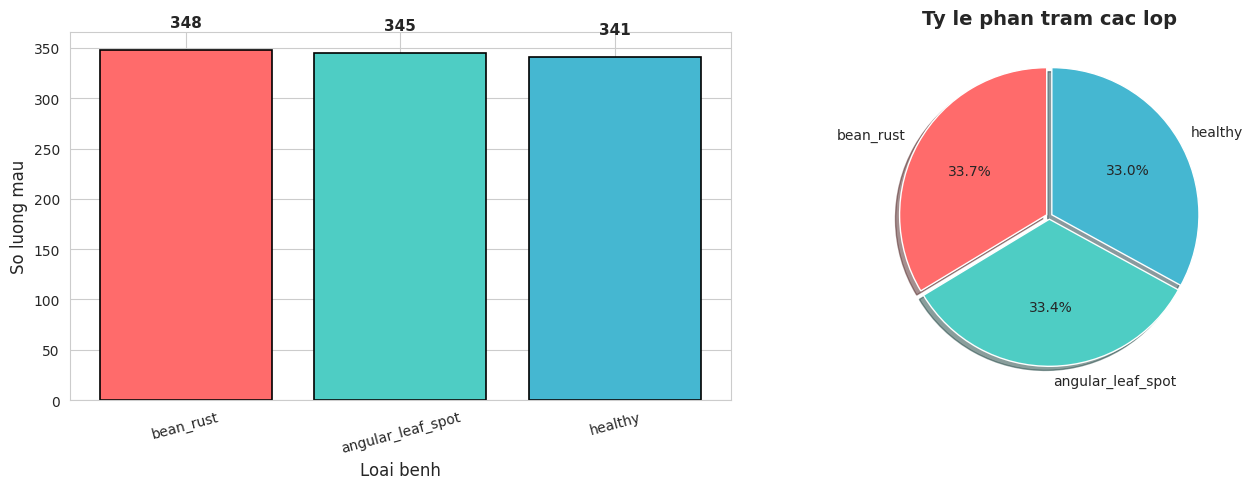


Da luu bieu do: class_distribution.png


In [17]:
# Thong ke ve cac lop
print("Phan bo cac lop:")
class_distribution = df['label'].value_counts()
print(class_distribution)
# Visualize phan bo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Bar chart
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = axes[0].bar(class_distribution.index, class_distribution.values, color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_xlabel('Loai benh', fontsize=12)
axes[0].set_ylabel('So luong mau', fontsize=12)
axes[0].tick_params(axis='x', rotation=15)
# Them so lieu tren bar
for bar, value in zip(bars, class_distribution.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
                 str(value), ha='center', va='bottom', fontweight='bold', fontsize=11)

# Pie chart
axes[1].pie(class_distribution.values, labels=class_distribution.index, autopct='%1.1f%%',
            colors=colors, explode=[0.02]*len(class_distribution), shadow=True, startangle=90)
axes[1].set_title('Ty le phan tram cac lop', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nDa luu bieu do: class_distribution.png")

 #### Số lượng mẫu giữa ba lớp bean_rust, angular_leaf_spot và healthy là khá đồng đều, lần lượt khoảng 348, 345 và 341 ảnh, tương ứng với tỷ lệ xấp xỉ 33–34% cho mỗi lớp. Sự chênh lệch giữa các lớp là không đáng kể, cho thấy dataset gần như cân bằng và không tồn tại hiện tượng mất cân bằng nghiêm trọng. Điều này là một lợi thế trong quá trình huấn luyện mô hình học sâu, vì mô hình sẽ không bị thiên lệch về một lớp cụ thể. Nhược điểm là có khá ít dữ liệu cho dataset này chỉ có 1034 ảnh cho training set và 133 ảnh cho valid set. Nên tăng cường dữ liệu ảnh mạnh hơn để cho mô hình học tốt hơn 

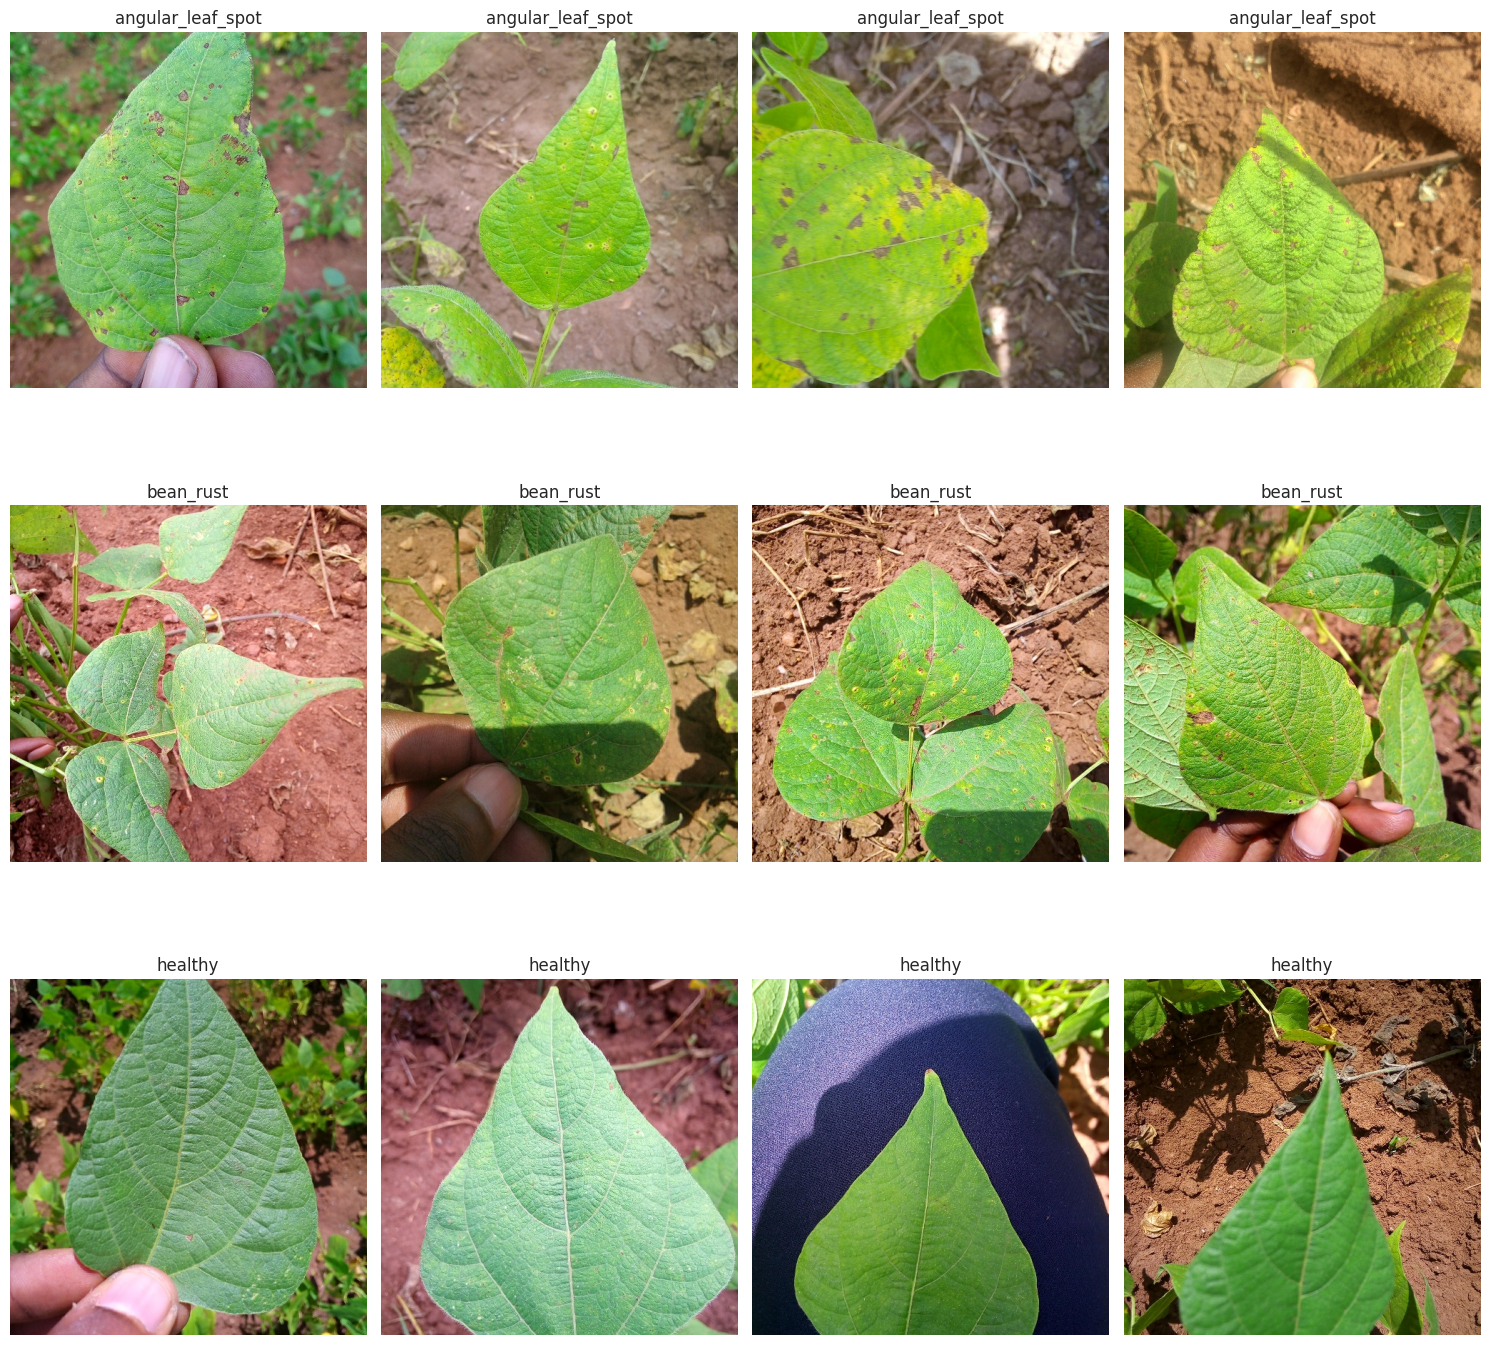

In [18]:
def visualize_samples(df, n_samples=3):
    plt.figure(figsize=(15, 5*len(CLASSES)))
    for idx, label in enumerate(CLASSES):
        # Lấy ngẫu nhiên n_samples ảnh thuộc label đó
        sample_df = df[df['label'] == label].sample(n_samples)
        
        for i, (_, row) in enumerate(sample_df.iterrows()):
            img_path = row['path']
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Chuyển BGR sang RGB
            
            plt.subplot(len(CLASSES), n_samples, idx*n_samples + i + 1)
            plt.imshow(img)
            plt.title(f"{label}", fontsize=12)
            plt.axis('off')
            
    plt.tight_layout()
    plt.show()

visualize_samples(df, n_samples=4)

### Angular leaf spot (bệnh đốm góc lá)
* Angular leaf spot là bệnh do vi khuẩn (Pseudomonas syringae pv. phaseolicola), xuất hiện phổ biến trên cây đậu trong điều kiện ẩm độ cao và mưa nhiều. Đây là bệnh nguy hiểm ở mức trung bình đến cao, vì có thể lây lan nhanh qua nước mưa, gió và tàn dư cây bệnh, đặc biệt trong giai đoạn sinh trưởng sớm. Về mặt hình thái, bệnh đặc trưng bởi các đốm nâu sẫm hoặc nâu xám, hình dạng góc cạnh, bị giới hạn rõ ràng bởi hệ gân lá, khiến tổn thương có dạng đa giác không đều. Các đốm thường xuất hiện rải rác hoặc liên kết thành mảng lớn, làm bề mặt lá loang lổ và giảm khả năng quang hợp. Vùng mô xung quanh đốm bệnh thường có màu xanh nhạt hoặc vàng nhẹ, tạo độ tương phản cao so với mô lá khỏe, đây là đặc điểm quan trọng giúp mô hình học sâu nhận diện tốt thông qua thông tin hình dạng và ranh giới tổn thương.
### Bean rust (bệnh gỉ sắt đậu)
* Bean rust là bệnh do nấm (Uromyces appendiculatus), được đánh giá là nguy hiểm, vì có khả năng làm giảm năng suất đáng kể nếu không được kiểm soát kịp thời. Bệnh phát triển mạnh trong điều kiện ẩm, nhiệt độ trung bình và có thể lây lan nhanh thông qua bào tử nấm trong không khí. Đặc trưng hình thái của bean rust là các đốm nhỏ, tròn hoặc bầu dục, màu nâu đỏ, nâu cam hoặc nâu gỉ sắt, thường xuất hiện với mật độ dày và phân bố khá đồng đều trên bề mặt lá. Các đốm bệnh không bị giới hạn bởi gân lá, kích thước tương đối đồng nhất và bề mặt đốm có thể hơi nổi. Mô lá xung quanh thường bị vàng hóa cục bộ, phản ánh sự suy giảm sinh lý của lá. So với angular leaf spot, bean rust có hình dạng đốm mềm và tròn hơn, ít cạnh sắc, đây là yếu tố phân biệt quan trọng về mặt hình học và texture đối với mô hình CNN.
### Healthy (lá khỏe mạnh)
* Lớp healthy đại diện cho lá đậu không bị nhiễm bệnh. Lá khỏe mạnh có bề mặt xanh đều, màu sắc đồng nhất, hệ gân lá rõ ràng và không xuất hiện bất kỳ đốm nâu, vàng hay vùng hoại tử nào. Kết cấu bề mặt lá mịn, ít nhiễu, không có sự gián đoạn về màu sắc hoặc cấu trúc. Lớp healthy có độ đồng nhất cao về màu sắc và texture,thiếu hoàn toàn các đặc trưng bất thường (lesions), giúp mô hình dễ dàng học được sự khác biệt giữa lá khỏe và lá bệnh. Tuy không phải là bệnh, nhưng lớp này có vai trò cực kỳ quan trọng trong việc giảm nhầm lẫn và nâng cao độ tin cậy của mô hình chẩn đoán.

Phan tich thuoc tinh anh...

Thong ke kich thuoc anh:
   Width  - Min: 500, Max: 500, Mean: 500.0
   Height - Min: 500, Max: 500, Mean: 500.0
   Channels (cac loai tim thay): {3}


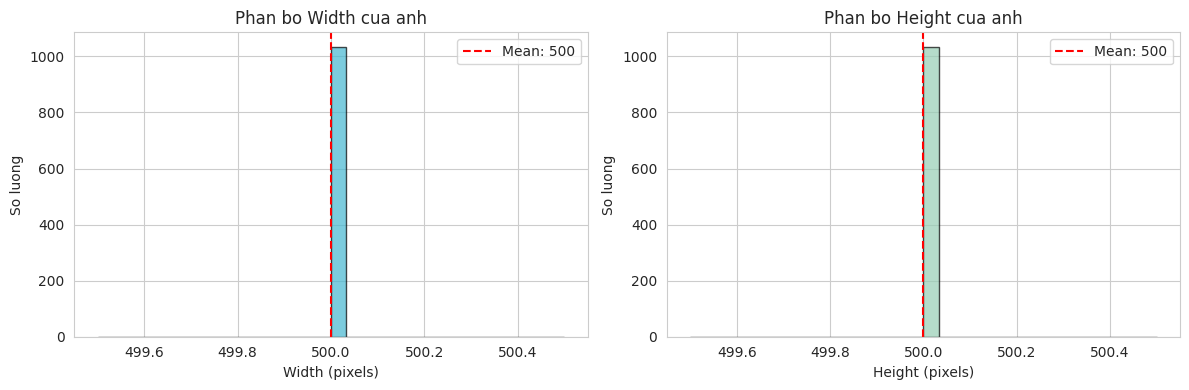

In [19]:
# Phân tích kích thước và thuộc tính ảnh
print("Phan tich thuoc tinh anh...")

img_widths = []
img_heights = []
img_channels = []

for img_path in df['path'].values: 
    if os.path.exists(img_path):
        try:
            with Image.open(img_path) as img:
                img_widths.append(img.size[0])
                img_heights.append(img.size[1])
                
                # Kiểm tra số kênh màu
                if img.mode == 'RGB':
                    img_channels.append(3)
                elif img.mode == 'L': # Grayscale
                    img_channels.append(1)
                elif img.mode == 'RGBA':
                    img_channels.append(4)
                else:
                    img_channels.append(len(img.getbands()))
        except Exception as e:
            print(f"Lỗi khi đọc ảnh {img_path}: {e}")

if len(img_widths) > 0:
    print(f"\nThong ke kich thuoc anh:")
    print(f"   Width  - Min: {min(img_widths)}, Max: {max(img_widths)}, Mean: {np.mean(img_widths):.1f}")
    print(f"   Height - Min: {min(img_heights)}, Max: {max(img_heights)}, Mean: {np.mean(img_heights):.1f}")
    print(f"   Channels (cac loai tim thay): {set(img_channels)}")

    # Histogram kich thuoc anh
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Biểu đồ Width
    axes[0].hist(img_widths, bins=30, color='#45B7D1', edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Width (pixels)')
    axes[0].set_ylabel('So luong')
    axes[0].set_title('Phan bo Width cua anh')
    axes[0].axvline(np.mean(img_widths), color='red', linestyle='--', label=f'Mean: {np.mean(img_widths):.0f}')
    axes[0].legend()

    # Biểu đồ Height
    axes[1].hist(img_heights, bins=30, color='#96CEB4', edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Height (pixels)')
    axes[1].set_ylabel('So luong')
    axes[1].set_title('Phan bo Height cua anh')
    axes[1].axvline(np.mean(img_heights), color='red', linestyle='--', label=f'Mean: {np.mean(img_heights):.0f}')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy ảnh nào hoặc lỗi đường dẫn!")

#### Toàn bộ 1167 ảnh trong dataset đều có cùng một kích thước duy nhất là 500 x 500 pixels (Width = 500, Height = 500).


In [20]:
print("Phan tich Brightness va Contrast...")

img_brightness = []
img_contrast = []
for img_path in tqdm(df['path'].values, desc="Analyzing"):
    if os.path.exists(img_path):
        # Đọc ảnh bằng OpenCV
        img = cv2.imread(img_path)
        if img is not None:
            # Chuyển sang ảnh xám để tính độ sáng
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img_brightness.append(np.mean(gray))
            img_contrast.append(np.std(gray))
        else:
            print(f"Không thể đọc file ảnh: {img_path}")

# Hiển thị kết quả thống kê
if len(img_brightness) > 0:
    print(f"\nTong so anh da xu ly: {len(img_brightness)}")
    print(f"Brightness - Min: {min(img_brightness):.1f}, Max: {max(img_brightness):.1f}, Mean: {np.mean(img_brightness):.1f}")
    print(f"Contrast   - Min: {min(img_contrast):.1f}, Max: {max(img_contrast):.1f}, Mean: {np.mean(img_contrast):.1f}")

    # Danh gia sơ bộ
    dark_images = sum(1 for b in img_brightness if b < 80)
    bright_images = sum(1 for b in img_brightness if b > 180)
    low_contrast = sum(1 for c in img_contrast if c < 30)

    print(f"\nAnh toi (brightness < 80): {dark_images} ({dark_images/len(img_brightness)*100:.1f}%)")
    print(f"Anh sang qua (brightness > 180): {bright_images} ({bright_images/len(img_brightness)*100:.1f}%)")
    print(f"Anh tuong phan thap (contrast < 30): {low_contrast} ({low_contrast/len(img_contrast)*100:.1f}%)")
else:
    print("Không có dữ liệu ảnh để phân tích.")

Phan tich Brightness va Contrast...


Analyzing: 100%|██████████| 1034/1034 [00:09<00:00, 113.29it/s]


Tong so anh da xu ly: 1034
Brightness - Min: 60.8, Max: 181.2, Mean: 123.6
Contrast   - Min: 22.9, Max: 74.9, Mean: 44.9

Anh toi (brightness < 80): 27 (2.6%)
Anh sang qua (brightness > 180): 1 (0.1%)
Anh tuong phan thap (contrast < 30): 49 (4.7%)


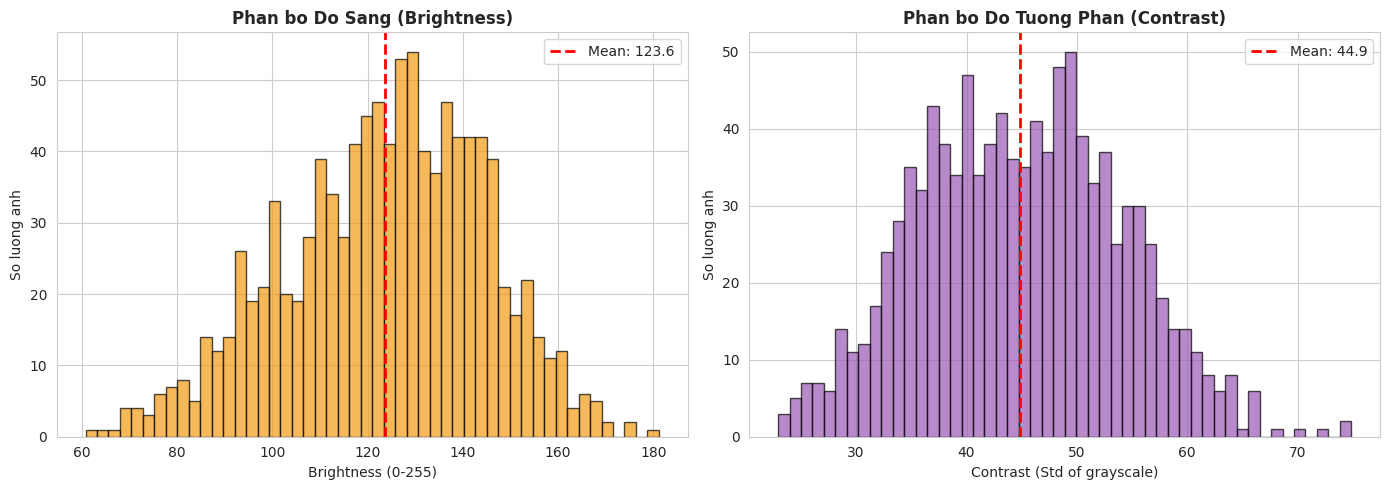

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(img_brightness, bins=50, color='#f39c12', edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(img_brightness), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(img_brightness):.1f}')
axes[0].set_xlabel('Brightness (0-255)')
axes[0].set_ylabel('So luong anh')
axes[0].set_title('Phan bo Do Sang (Brightness)', fontweight='bold')
axes[0].legend()
axes[1].hist(img_contrast, bins=50, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[1].axvline(np.mean(img_contrast), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(img_contrast):.1f}')
axes[1].set_xlabel('Contrast (Std of grayscale)')
axes[1].set_ylabel('So luong anh')
axes[1].set_title('Phan bo Do Tuong Phan (Contrast)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

### Chất lượng ánh sáng của dataset nhìn chung khá tốt và ổn định. Độ sáng trung bình ở mức 123.6, nằm trong khoảng hợp lý cho ảnh ngoài trời, trong khi độ tương phản trung bình 44.9 cho thấy chi tiết lá và vùng bệnh được thể hiện tương đối rõ. Tỷ lệ ảnh quá tối chỉ 2.6% và ảnh quá sáng gần như không đáng kể (0.1%), chứng tỏ dữ liệu ít bị nhiễu do điều kiện chiếu sáng cực đoan. Ngoài ra, chỉ khoảng 4.7% ảnh có độ tương phản thấp, nghĩa là phần lớn ảnh vẫn giữ được sự phân tách tốt giữa nền lá và vùng tổn thương. Tổng thể, dataset có chất lượng ánh sáng đồng đều, ít ảnh “xấu”, phù hợp để huấn luyện mô hình CNN mà không cần xử lý mạnh tay, chỉ nên bổ sung augmentation nhẹ về brightness/contrast để tăng khả năng tổng quát hóa.

Phan tich phan bo mau sac RGB...


Analyzing RGB: 100%|██████████| 100/100 [00:06<00:00, 14.44it/s]


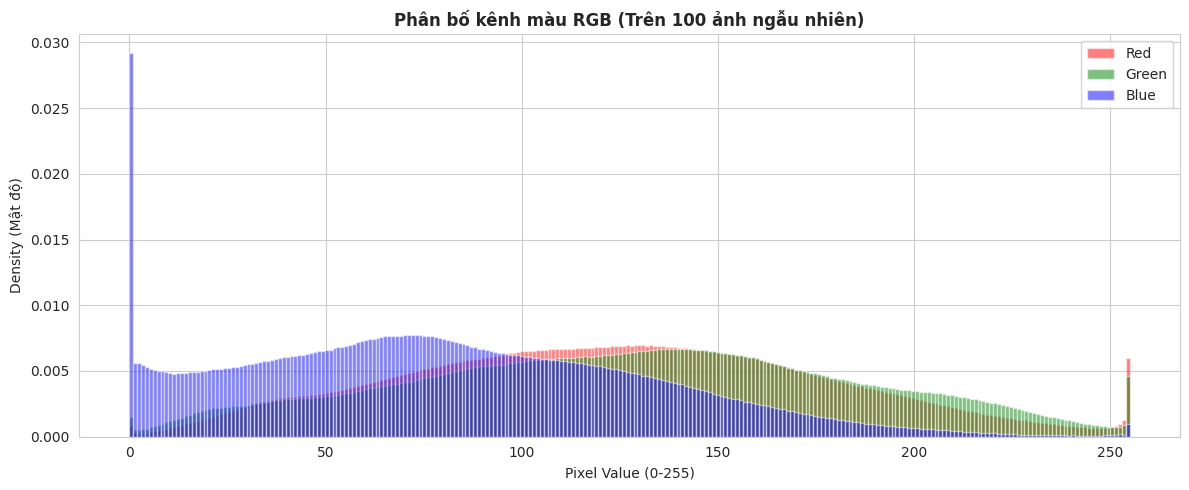

In [23]:

print("Phan tich phan bo mau sac RGB...")
sample_size = min(100, len(df))

sample_imgs = df['path'].sample(sample_size).values

all_r, all_g, all_b = [], [], []

# Duyệt qua các ảnh mẫu
for img_path in tqdm(sample_imgs, desc="Analyzing RGB"):
    if os.path.exists(img_path):
        img = cv2.imread(img_path)
        if img is not None:
            # Chuyển từ BGR (mặc định của OpenCV) sang RGB
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Làm phẳng mảng (flatten) để lấy tất cả giá trị pixel vào list
            all_r.extend(img_rgb[:, :, 0].flatten())
            all_g.extend(img_rgb[:, :, 1].flatten())
            all_b.extend(img_rgb[:, :, 2].flatten())

# Vẽ biểu đồ Histogram
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(all_r, bins=256, color='red', alpha=0.5, label='Red', density=True)
ax.hist(all_g, bins=256, color='green', alpha=0.5, label='Green', density=True)
ax.hist(all_b, bins=256, color='blue', alpha=0.5, label='Blue', density=True)

ax.set_xlabel('Pixel Value (0-255)')
ax.set_ylabel('Density (Mật độ)')
ax.set_title('Phân bố kênh màu RGB (Trên 100 ảnh ngẫu nhiên)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Biểu đồ phân bố RGB cho thấy đặc trưng màu sắc của dataset chịu chi phối mạnh bởi kênh xanh lá (Green). Kênh Green tập trung nhiều ở vùng giá trị trung–cao (khoảng 120–200), phản ánh nền lá xanh chiếm ưu thế và là nguồn thông tin chính để phân biệt lá khỏe và lá bệnh. Kênh Red phân bố ở mức trung bình, đóng vai trò quan trọng trong việc nhận diện các vùng bệnh có màu nâu, đỏ hoặc vàng – đặc biệt là bean rust và angular eaf spot. Trong khi đó, kênh Blue có mật độ cao ở vùng giá trị thấp.

### Ngoài ra, đỉnh lớn gần giá trị 0 ở kênh Blue cho thấy tồn tại một số vùng tối hoặc nền đất/bóng đổ trong ảnh, nhưng không chiếm tỷ lệ áp đảo. Tổng thể, phân bố RGB tương đối mượt -> chứng tỏ ảnh ít bị cháy sáng hay mất chi tiết
